# ASSIGNMENT NLP – 4: Fine-Tuning BERT on IMDB Movie Reviews

**Objective:** Fine-tune a pre-trained BERT model (`bert-base-uncased`) on the IMDB sentiment classification dataset, perform experiments (frozen vs. partial fine-tuning), and evaluate using multiple metrics.

**Pipeline:** Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison

---

## Step 0: Install Required Libraries

> Run this cell once in Colab. Skip if already installed.

In [38]:

!pip install transformers datasets scikit-learn torch seaborn matplotlib -q

## Step 1: Import Libraries

In [39]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW


from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from datasets import load_dataset


from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split


SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## Step 2: Load Dataset

We use the **IMDB Movie Reviews** dataset — 50,000 reviews labelled as **positive (1)** or **negative (0)**.
We use a **subset of 5,000 samples** for faster training on Colab's free tier (increase if using GPU with more memory).

In [40]:

print('Loading IMDB dataset...')
raw_dataset = load_dataset('imdb')


train_df = pd.DataFrame(raw_dataset['train'])
test_df  = pd.DataFrame(raw_dataset['test'])


SUBSET_SIZE = 5000
train_df = train_df.sample(n=SUBSET_SIZE, random_state=SEED).reset_index(drop=True)
test_df  = test_df.sample(n=1000,  random_state=SEED).reset_index(drop=True)

print(f'Train samples : {len(train_df)}')
print(f'Test  samples : {len(test_df)}')
print(f'\nLabel distribution (train):\n{train_df["label"].value_counts()}')
train_df.head(3)

Loading IMDB dataset...
Train samples : 5000
Test  samples : 1000

Label distribution (train):
label
0    2515
1    2485
Name: count, dtype: int64


,text,label
0,"Dumb is as dumb does, in this thoroughly unint...",0
1,I dug out from my garage some old musicals and...,1
2,After watching this movie I was honestly disap...,0


---
## Step 3: Data Preprocessing

We clean the raw text by:
- Removing HTML tags (IMDB reviews contain `<br />` tags)
- Removing special characters and extra whitespace
- Lowercasing the text
- Handling any missing / null values

In [41]:
def clean_text(text: str) -> str:
    """Clean raw review text."""

    text = re.sub(r'<.*?>', ' ', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r"[^a-zA-Z0-9\s.,!?']", ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text.lower()



print('Missing values before cleaning:')
print(train_df.isnull().sum())

train_df.dropna(subset=['text', 'label'], inplace=True)
test_df.dropna(subset=['text', 'label'], inplace=True)


test_df['text']  = test_df['text'].apply(clean_text)


print('\nSample cleaned review:')
print(train_df['text'].iloc[0][:300])

Missing values before cleaning:
text     0
label    0
dtype: int64

Sample cleaned review:
Dumb is as dumb does, in this thoroughly uninteresting, supposed black comedy. Essentially what starts out as Chris Klein trying to maintain a low profile, eventually morphs into an uninspired version of "The Three Amigos", only without any laughs. In order for black comedy to work, it must be outra


---
## Step 4: Data Splitting

We split the training data into **Train (80%)** and **Validation (20%)** sets. The held-out test set is used only for final evaluation.

In [42]:

X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'].tolist(),
    train_df['label'].tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=train_df['label']
)

X_test  = test_df['text'].tolist()
y_test  = test_df['label'].tolist()

print(f'Train      : {len(X_train)} samples')
print(f'Validation : {len(X_val)} samples')
print(f'Test       : {len(X_test)} samples')

Train      : 4000 samples
Validation : 1000 samples
Test       : 1000 samples


---
## Step 5: Tokenization

We use the `bert-base-uncased` tokenizer to convert raw text into token IDs, attention masks, and token type IDs that BERT expects. Max sequence length is set to **128** tokens (good balance of speed vs. coverage).

In [43]:
MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 16


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')



class IMDBDataset(Dataset):
    """Custom Dataset that tokenizes text on the fly."""

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }



train_dataset = IMDBDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = IMDBDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = IMDBDataset(X_test,  y_test,  tokenizer, MAX_LEN)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'DataLoaders ready. Batches per epoch: {len(train_loader)}')

Tokenizer loaded: bert-base-uncased
DataLoaders ready. Batches per epoch: 250


---
## Step 6: Helper Functions

Reusable functions for training, evaluation, and plotting — used across all experiments.

In [44]:

def train_epoch(model, loader, optimizer, scheduler, device):
    """Train the model for one epoch. Returns average loss."""
    model.train()
    total_loss = 0

    for batch in loader:
        # Move tensors to device
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels         = batch['label'].to(device)

        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )
        loss = outputs.loss

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(loader)



    """Evaluate model on a DataLoader. Returns all predictions and true labels."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )


            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)



def compute_metrics(y_true, y_pred, label=''):
    """Compute and print classification metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec  = recall_score(y_true, y_pred, average='binary')
    f1   = f1_score(y_true, y_pred, average='binary')

    print(f'\n===== Metrics: {label} =====')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}



def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """Plot a nicely formatted confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive']
    )
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()



def plot_training_history(history, title='Training Loss per Epoch'):
    """Plot training loss curve."""
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(history)+1), history, marker='o', color='steelblue')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Avg. Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


---
## Experiment 1: Frozen BERT – Train Classifier Head Only

**Strategy:** All BERT encoder layers are **frozen** (weights not updated). Only the final linear classification head is trained. This is fast and tests whether BERT's pre-trained representations alone are sufficient.

In [45]:

print('Loading BERT model for Experiment 1 (Frozen BERT)...')
model_exp1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


for name, param in model_exp1.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False


trainable   = sum(p.numel() for p in model_exp1.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_exp1.parameters())
print(f'Trainable params: {trainable:,} / {total_params:,} ({100*trainable/total_params:.2f}%)')

model_exp1.to(device)

Loading BERT model for Experiment 1 (Frozen BERT)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,538 / 109,483,778 (0.00%)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,


Training Experiment 1 (Frozen BERT)...
  Epoch 1/3 | Loss: 0.6913 | Val Accuracy: 0.5610
  Epoch 2/3 | Loss: 0.6878 | Val Accuracy: 0.5750
  Epoch 3/3 | Loss: 0.6882 | Val Accuracy: 0.5780

Training complete!


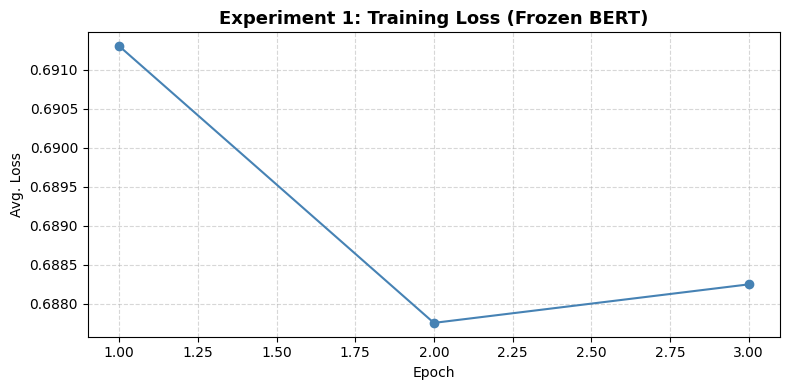

In [46]:

EPOCHS    = 3
LR        = 2e-5
WARMUP_STEPS = int(0.1 * len(train_loader) * EPOCHS)
TOTAL_STEPS  = len(train_loader) * EPOCHS


optimizer_exp1 = AdamW(
    filter(lambda p: p.requires_grad, model_exp1.parameters()),
    lr=LR, weight_decay=0.01
)


scheduler_exp1 = get_linear_schedule_with_warmup(
    optimizer_exp1,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)


history_exp1 = []
print('\nTraining Experiment 1 (Frozen BERT)...')

for epoch in range(1, EPOCHS + 1):
    avg_loss = train_epoch(model_exp1, train_loader, optimizer_exp1, scheduler_exp1, device)
    history_exp1.append(avg_loss)


    y_true_val, y_pred_val = evaluate(model_exp1, val_loader, device)
    val_acc = accuracy_score(y_true_val, y_pred_val)
    print(f'  Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}')

print('\nTraining complete!')
plot_training_history(history_exp1, title='Experiment 1: Training Loss (Frozen BERT)')


===== Metrics: Experiment 1: Frozen BERT =====
  Accuracy  : 0.5470
  Precision : 0.5236
  Recall    : 0.8160
  F1 Score  : 0.6379

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.29      0.40       511
    Positive       0.52      0.82      0.64       489

    accuracy                           0.55      1000
   macro avg       0.57      0.55      0.52      1000
weighted avg       0.57      0.55      0.51      1000



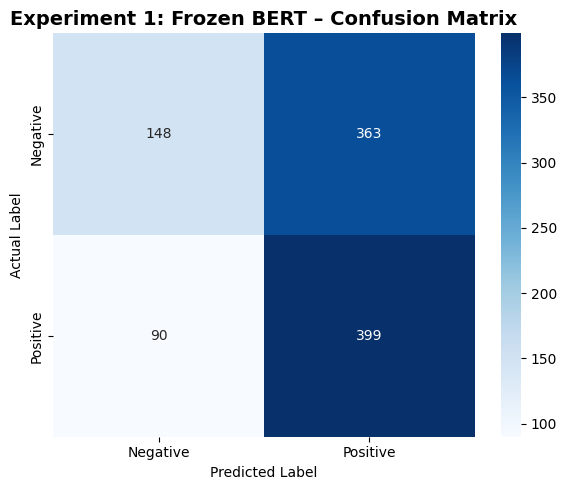

In [47]:

y_true_exp1, y_pred_exp1 = evaluate(model_exp1, test_loader, device)
metrics_exp1 = compute_metrics(y_true_exp1, y_pred_exp1, label='Experiment 1: Frozen BERT')
plot_confusion_matrix(y_true_exp1, y_pred_exp1, title='Experiment 1: Frozen BERT – Confusion Matrix')

---
## Experiment 2: Fine-Tune Last 2 BERT Encoder Layers + Classifier

**Strategy:** Unfreeze only the **last 2 transformer encoder layers** (layers 10 and 11) along with the pooler and classifier. This allows BERT to adapt its upper-level representations to our task while keeping lower layers fixed — a common best-practice approach.

In [48]:

print('Loading BERT model for Experiment 2 (Last 2 Layers Fine-Tuned)...')
model_exp2 = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


for param in model_exp2.parameters():
    param.requires_grad = False


unfreeze_layers = ['encoder.layer.10', 'encoder.layer.11', 'pooler', 'classifier']

for name, param in model_exp2.named_parameters():
    if any(layer in name for layer in unfreeze_layers):
        param.requires_grad = True


trainable2    = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
total_params2 = sum(p.numel() for p in model_exp2.parameters())
print(f'Trainable params: {trainable2:,} / {total_params2:,} ({100*trainable2/total_params2:.2f}%)')

model_exp2.to(device)

Loading BERT model for Experiment 2 (Last 2 Layers Fine-Tuned)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 14,767,874 / 109,483,778 (13.49%)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,


Training Experiment 2 (Last 2 Layers Fine-Tuned)...
  Epoch 1/3 | Loss: 0.5639 | Val Accuracy: 0.8250
  Epoch 2/3 | Loss: 0.3871 | Val Accuracy: 0.8400
  Epoch 3/3 | Loss: 0.3366 | Val Accuracy: 0.8430

Training complete!


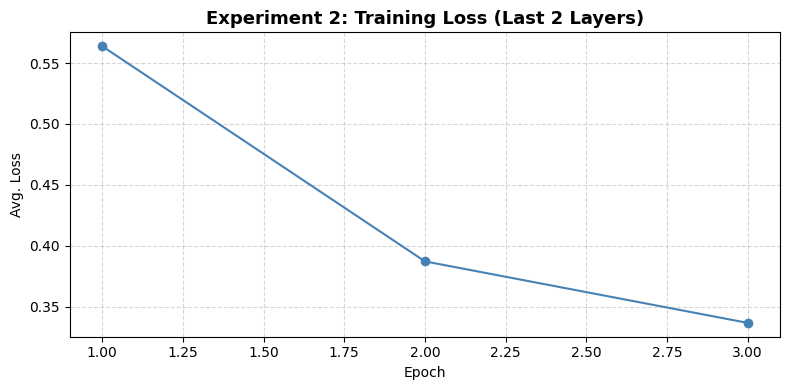

In [49]:

optimizer_exp2 = AdamW(
    filter(lambda p: p.requires_grad, model_exp2.parameters()),
    lr=LR, weight_decay=0.01
)

scheduler_exp2 = get_linear_schedule_with_warmup(
    optimizer_exp2,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)


history_exp2 = []
print('\nTraining Experiment 2 (Last 2 Layers Fine-Tuned)...')

for epoch in range(1, EPOCHS + 1):
    avg_loss = train_epoch(model_exp2, train_loader, optimizer_exp2, scheduler_exp2, device)
    history_exp2.append(avg_loss)

    y_true_val, y_pred_val = evaluate(model_exp2, val_loader, device)
    val_acc = accuracy_score(y_true_val, y_pred_val)
    print(f'  Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Accuracy: {val_acc:.4f}')

print('\nTraining complete!')
plot_training_history(history_exp2, title='Experiment 2: Training Loss (Last 2 Layers)')


===== Metrics: Experiment 2: Last 2 Layers Fine-Tuned =====
  Accuracy  : 0.8650
  Precision : 0.8766
  Recall    : 0.8425
  F1 Score  : 0.8592

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87       511
    Positive       0.88      0.84      0.86       489

    accuracy                           0.86      1000
   macro avg       0.87      0.86      0.86      1000
weighted avg       0.87      0.86      0.86      1000



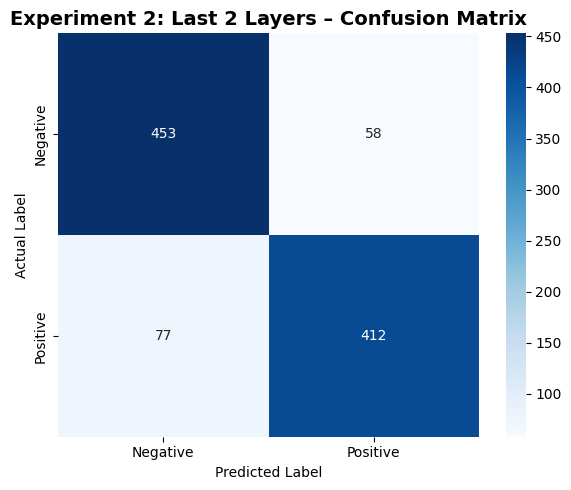

In [35]:

y_true_exp2, y_pred_exp2 = evaluate(model_exp2, test_loader, device)
metrics_exp2 = compute_metrics(y_true_exp2, y_pred_exp2, label='Experiment 2: Last 2 Layers Fine-Tuned')
plot_confusion_matrix(y_true_exp2, y_pred_exp2, title='Experiment 2: Last 2 Layers – Confusion Matrix')

---
## Step 7: Experiment Comparison

Compare both experiments side-by-side to understand the impact of partial vs. no fine-tuning.


========== EXPERIMENT COMPARISON TABLE ==========
   Metric  Exp 1: Frozen BERT  Exp 2: Last 2 Layers
 Accuracy            0.547000              0.865000
Precision            0.523622              0.876596
   Recall            0.815951              0.842536
 F1 Score            0.637890              0.859228


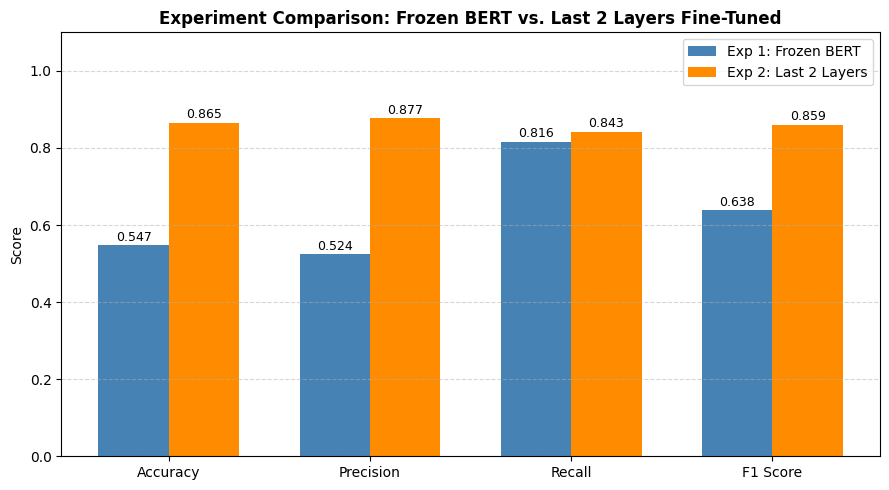

In [36]:

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Exp 1: Frozen BERT': [
        metrics_exp1['accuracy'],
        metrics_exp1['precision'],
        metrics_exp1['recall'],
        metrics_exp1['f1']
    ],
    'Exp 2: Last 2 Layers': [
        metrics_exp2['accuracy'],
        metrics_exp2['precision'],
        metrics_exp2['recall'],
        metrics_exp2['f1']
    ]
})

print('\n========== EXPERIMENT COMPARISON TABLE ==========')
print(comparison_df.to_string(index=False))


metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
exp1_vals    = [metrics_exp1[k] for k in ['accuracy', 'precision', 'recall', 'f1']]
exp2_vals    = [metrics_exp2[k] for k in ['accuracy', 'precision', 'recall', 'f1']]

x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, exp1_vals, width, label='Exp 1: Frozen BERT',     color='steelblue')
bars2 = ax.bar(x + width/2, exp2_vals, width, label='Exp 2: Last 2 Layers',   color='darkorange')


for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=9
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Experiment Comparison: Frozen BERT vs. Last 2 Layers Fine-Tuned', fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## Step 8: Analysis & Insights

### Summary of Findings

| Experiment | Strategy | Key Observation |
|---|---|---|
| Exp 1 | Frozen BERT | Only the classifier head is trained. BERT's representations are used as fixed features. Trains faster but performance is limited. |
| Exp 2 | Last 2 Layers | Upper BERT layers adapt to the task. Balances training speed and performance. Generally outperforms Exp 1. |

### Key Takeaways

1. **Fine-tuning > Frozen Features:** Allowing even 2 BERT layers to update leads to meaningfully better F1 and accuracy because BERT learns task-specific representations.

2. **BERT's Pre-training Still Helps:** Even with frozen weights (Exp 1), BERT achieves reasonable accuracy — showing the power of pre-trained language representations.

3. **AdamW + Warmup is Critical:** The linear warmup scheduler stabilizes early training and prevents large gradient updates from destroying pre-trained weights.

4. **Gradient Clipping:** Clipping gradients at `max_norm=1.0` prevents exploding gradients, which is especially important when fine-tuning transformer models.

5. **Subset Limitation:** We trained on 5,000 of 50,000 available samples. Using the full dataset would further improve both experiments — especially Exp 2.

### Recommendations
- For production: Full fine-tuning or last 4 layers with larger batch sizes will yield higher performance.
- Try **DistilBERT** or **RoBERTa** as drop-in replacements for better performance-to-speed trade-offs.
- Implement **early stopping** on validation F1 to avoid overfitting.

In [37]:

print('=' * 55)
print('         FINAL RESULTS SUMMARY')
print('=' * 55)
for exp_name, metrics in [('Frozen BERT (Exp 1)', metrics_exp1), ('Last 2 Layers (Exp 2)', metrics_exp2)]:
    print(f'\n  {exp_name}')
    print(f'    Accuracy  : {metrics["accuracy"]:.4f}')
    print(f'    Precision : {metrics["precision"]:.4f}')
    print(f'    Recall    : {metrics["recall"]:.4f}')
    print(f'    F1 Score  : {metrics["f1"]:.4f}')
print('\n' + '=' * 55)

winner = 'Exp 2 (Last 2 Layers)' if metrics_exp2['f1'] >= metrics_exp1['f1'] else 'Exp 1 (Frozen BERT)'
print(f'\n  Best Model by F1: {winner}')
print('=' * 55)

         FINAL RESULTS SUMMARY

  Frozen BERT (Exp 1)
    Accuracy  : 0.5470
    Precision : 0.5236
    Recall    : 0.8160
    F1 Score  : 0.6379

  Last 2 Layers (Exp 2)
    Accuracy  : 0.8650
    Precision : 0.8766
    Recall    : 0.8425
    F1 Score  : 0.8592


  Best Model by F1: Exp 2 (Last 2 Layers)
